# TSFC Demo

A demo of the **Time Series Forecasting with Learned Mixtures** project.

This notebook:
1. **Explores data** from the GiftEvalPretrain `weather` subset
2. **Trains three mixture configurations** on-the-fly (static, adaptive, adaptive+boosting)
3. **Compares results** in a unified table (mixture variants + individual backbone models)
4. **Visualises training / validation metrics** from TensorBoard logs
5. **Plots learned mixture weights** for `chronos2` and `moirai2` across runs

> **Models used:** `chronos2` and `moirai2` only (TimesFM excluded).

> **Before running:** make sure you have installed the relevant extras:
> ```bash
> uv sync --extra chronos --extra moirai --extra dev
> ```

## Setup

In [2]:
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [18]:
# ---------------------------------------------------------------------------
# Configuration — adjust these to trade speed vs. quality
# ---------------------------------------------------------------------------

REPO_ROOT = Path.cwd()        # must be the project root
LOG_DIR = REPO_ROOT / "logs"

SUBSET = "weather"            # GiftEvalPretrain subset
MODEL_NAMES = ["chronos2", "moirai2"]

DEVICE = "cpu"                # change to "cuda" if a GPU is available
EPOCHS = 10                   # increase for better convergence (≥ 30 recommended)
MAX_SERIES = 1                # series per subset (increase for real evaluation)
BATCH_SIZE = 4
VAL_EVERY = 2                 # run validation every N epochs

print(f"Repo root : {REPO_ROOT}")
print(f"Log dir   : {LOG_DIR}")
print(f"Models    : {MODEL_NAMES}")
print(f"Subset    : {SUBSET}")
print(f"Device    : {DEVICE}  |  Epochs: {EPOCHS}  |  Max series: {MAX_SERIES}")

Repo root : /mnt/data_2/abenechehab/gifteval_challenge
Log dir   : /mnt/data_2/abenechehab/gifteval_challenge/logs
Models    : ['chronos2', 'moirai2']
Subset    : weather
Device    : cpu  |  Epochs: 10  |  Max series: 1


---
## Part 1 — Data Exploration

We use `scripts/explore_data.py` to inspect subset shapes, frequencies, and NaN rates.

In [4]:
result = subprocess.run(
    [
        sys.executable, "scripts/explore_data.py",
        "--subsets", SUBSET,
        "--max_series", str(MAX_SERIES),
    ],
    capture_output=True, text=True, cwd=REPO_ROOT,
)
print(result.stdout or "(no stdout)")
if result.returncode != 0:
    print("[ERROR] stderr:", result.stderr[-2000:])


Subset: 'weather'  (3018 series)
  [   0] item_id='T1'                            shape=(1,100057)  freq=H         nan%=0.0

  Lengths : min=100057, median=100057, max=100057
  NaN frac: mean=0.00%
  Freqs   : ['H']
  #variates: [1]



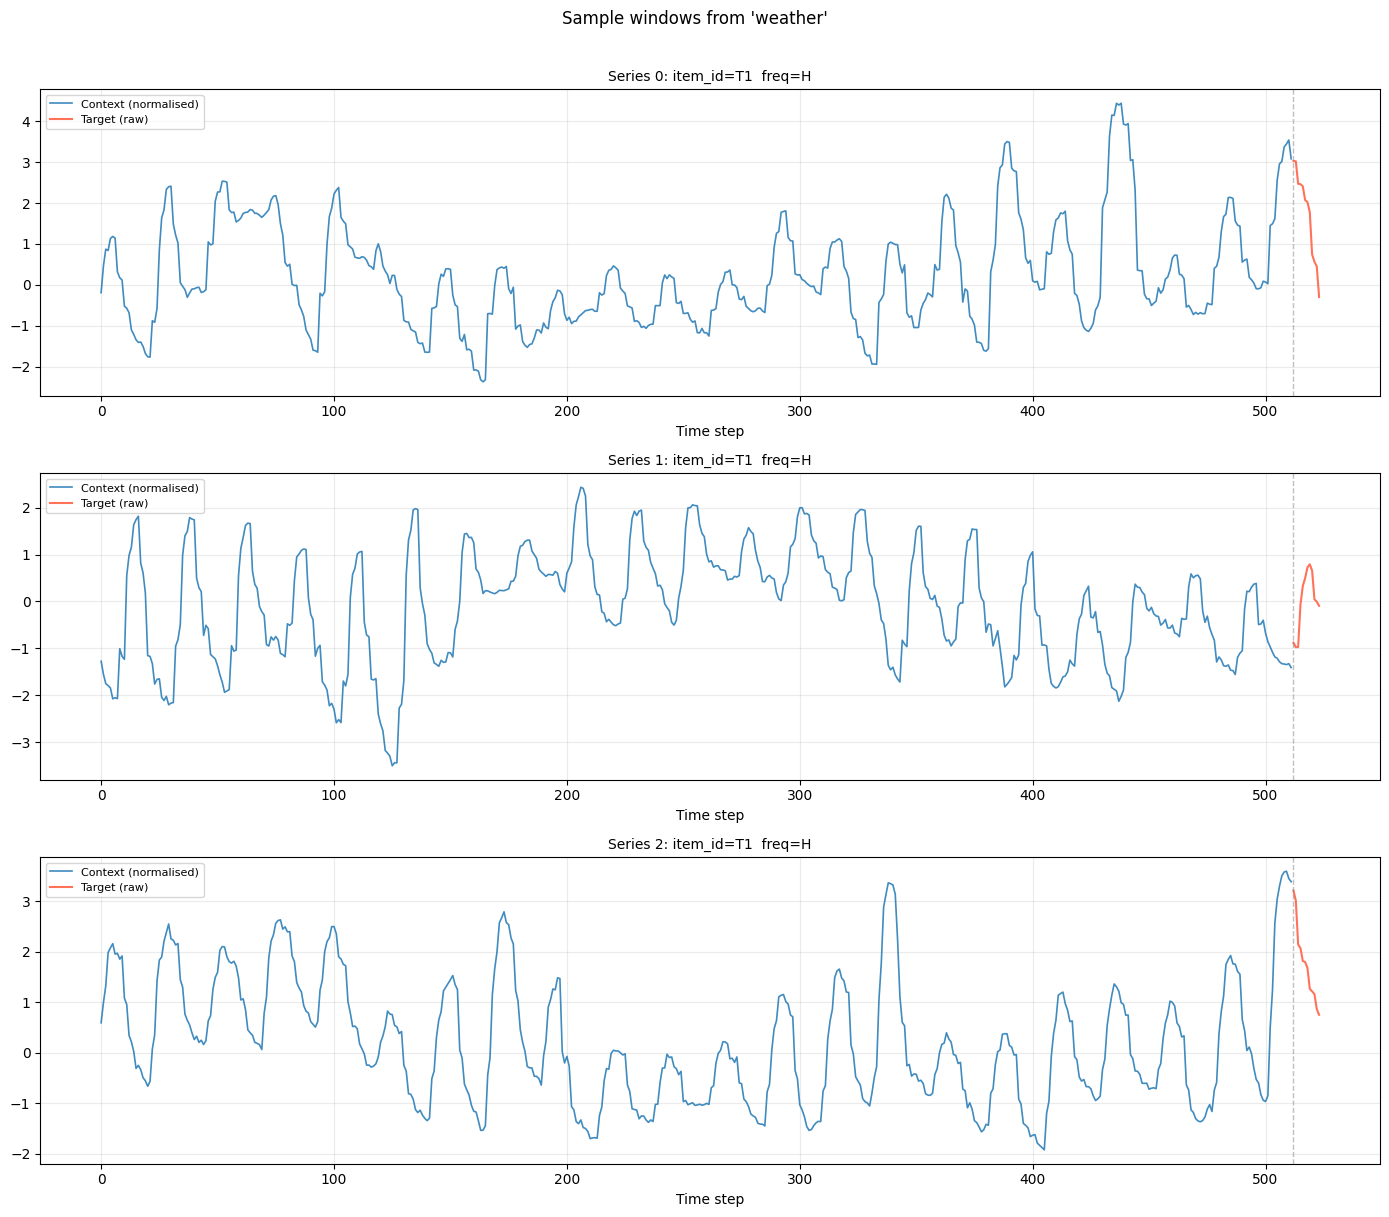

In [6]:
from tsfc.data.gifteval import GiftEvalDataset

ds = GiftEvalDataset(
    subset_names=[SUBSET],
    context_length=512,
    split="train",
    max_series_per_subset=1,
)

n_plot = min(3, len(ds))
fig, axes = plt.subplots(n_plot, 1, figsize=(14, 4 * n_plot))
if n_plot == 1:
    axes = [axes]

for i in range(n_plot):
    item = ds[i]
    ctx = item["context"].numpy()[0]       # first variate, normalised
    tgt = item["target"].numpy()[0]    # first variate, raw scale

    t_ctx = list(range(len(ctx)))
    t_tgt = list(range(len(ctx), len(ctx) + len(tgt)))

    ax = axes[i]
    ax.plot(t_ctx, ctx, label="Context (normalised)", lw=1.2, alpha=0.85)
    ax.plot(t_tgt, tgt, label="Target (raw)", color="tomato", lw=1.5, alpha=0.9)
    ax.axvline(len(ctx), color="gray", linestyle="--", lw=1, alpha=0.5)
    ax.set_title(f"Series {i}: item_id={item['item_id']}  freq={item['freq']}", fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel("Time step")
    ax.grid(alpha=0.25)

plt.suptitle(f"Sample windows from '{SUBSET}'", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 2 — Training Three Mixture Configurations

| Run | Config | Description |
|-----|--------|-------------|
| `static` | default | Global scalar log-weights (no MLP, no booster) |
| `adaptive` | `--adaptive` | Per-instance `MetaWeighter` MLP produces weights |
| `adaptive_boosting` | `--adaptive --boosting` | Adaptive weights **+** patch-transformer residual head |

Each run calls `train_mixture_online.py` as a subprocess and captures the run directory from the log output.

In [19]:
def run_training(run_name: str, extra_args: list) -> "Path | None":
    """Call train_mixture_online.py and return the created run directory."""
    base_cmd = [
        sys.executable, "scripts/train_mixture_online.py",
        "--subsets", SUBSET,
        "--model_names", *MODEL_NAMES,
        "--device", DEVICE,
        "--epochs", str(EPOCHS),
        "--max_series_per_subset", str(MAX_SERIES),
        "--batch_size", str(BATCH_SIZE),
        "--val_every_n_epochs", str(VAL_EVERY),
        "--log_every_n_steps", "5",
        "--run_name", run_name,
    ]
    cmd = base_cmd + extra_args

    print(f"\n{'='*60}")
    print(f"Run: {run_name}")
    print(f"Extra args: {extra_args}")
    print(f"{'='*60}")

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=REPO_ROOT)

    # Extract run directory from logger output (stderr)
    m = re.search(r"Run directory: (.+)", result.stderr)
    if m:
        run_dir = Path(m.group(1).strip())
    else:
        # Fallback: find the most recently created matching directory
        matches = sorted(LOG_DIR.glob(f"*_{run_name}"))
        run_dir = matches[-1] if matches else None

    if result.returncode != 0:
        print(f"[FAILED] Return code: {result.returncode}")
        print("--- Last 2000 chars of stderr ---")
        print(result.stderr[-2000:])
    else:
        print(f"[OK] Run dir: {run_dir}")
        # Print the final table that the script writes to stdout
        for line in result.stdout.strip().split("\n")[-20:]:
            print(line)

    return run_dir

In [20]:
run_dirs: dict = {}

# --- Run 1: Static mixture (global scalar weights) ---
run_dirs["static"] = run_training("static", [])

# --- Run 2: Adaptive mixture (per-instance MetaWeighter MLP) ---
run_dirs["adaptive"] = run_training("adaptive", ["--adaptive"])

# --- Run 3: Adaptive + BoostingForecaster residual head ---
run_dirs["adaptive_boosting"] = run_training(
    "adaptive_boosting",
    ["--adaptive", "--boosting", "--boosting_prediction_length", "12"],
)

print("\nAll runs complete.")
for k, v in run_dirs.items():
    print(f"  {k}: {v}")


Run: static
Extra args: []
[OK] Run dir: logs/2026-03-03_10-39-34_static
FINAL TEST RESULTS
Model                      Loss        MSE        MAE       MASE
----------------------------------------------------------------
mixture                  0.3393     0.0117     0.0726     0.3393
chronos2                 0.3621     0.0125     0.0775     0.3621
moirai2                  0.4133     0.0139     0.0885     0.4133
CSV:         logs/2026-03-03_10-39-34_static/results.csv
TensorBoard: tensorboard --logdir logs/2026-03-03_10-39-34_static

Run: adaptive
Extra args: ['--adaptive']
[OK] Run dir: logs/2026-03-03_10-44-02_adaptive
FINAL TEST RESULTS
Model                      Loss        MSE        MAE       MASE
----------------------------------------------------------------
mixture                  0.4083     0.0137     0.0874     0.4083
chronos2                 0.3621     0.0125     0.0775     0.3621
moirai2                  0.4133     0.0139     0.0885     0.4133
CSV:         logs/2026-03

---
## Part 3 — Unified Results Comparison

Each run writes a `results.csv` to its run directory. We load all three, pivot, and display a joint table that includes each mixture variant **and** the individual backbone model performances.

Columns are test-split metrics. **Green = best, Red = worst** per column.

In [21]:
DISPLAY_NAMES = {
    "static": "Static mixture",
    "adaptive": "Adaptive mixture",
    "adaptive_boosting": "Adaptive + Boosting",
}

dfs = []
for run_key, run_dir in run_dirs.items():
    if run_dir is None:
        print(f"Warning: no run directory for '{run_key}'")
        continue
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        print(f"Warning: {csv_path} not found")
        continue
    df = pd.read_csv(csv_path)
    df["run"] = run_key
    dfs.append(df)

# if not dfs:
#     print("No results found — did the training runs succeed?")


all_df = pd.concat(dfs, ignore_index=True)
all_df

,split,model,metric,value,run
0,test,mixture,loss,0.339264,static
1,test,mixture,mse,0.011659,static
2,test,mixture,mae,0.072650,static
3,test,mixture,mase,0.339264,static
4,test,chronos2,loss,0.362122,static
5,test,chronos2,mse,0.012541,static
6,test,chronos2,mae,0.077544,static
7,test,chronos2,mase,0.362122,static
8,test,moirai2,loss,0.413310,static
9,test,moirai2,mse,0.013857,static


In [22]:
# Ensure numeric values
all_df["value"] = pd.to_numeric(all_df["value"], errors="coerce")

# Pivot
pivot = (
    all_df.pivot_table(
        index=["run", "model"],
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

# -------------------------------------------------
# Build ordered rows: mixture first, then models
# -------------------------------------------------
row_order = []
for run_key in run_dirs:
    for model in ["mixture"] + MODEL_NAMES:
        sub = pivot[(pivot["run"] == run_key) & (pivot["model"] == model)]
        if not sub.empty:
            row_order.append(sub.index[0])

pivot = pivot.loc[row_order].reset_index(drop=True)

# -------------------------------------------------
# Build clean MultiIndex (guaranteed unique)
# -------------------------------------------------
display_runs = pivot["run"].map(lambda r: DISPLAY_NAMES.get(r, r))

pivot["display_run"] = display_runs
pivot["display_model"] = pivot["model"]

# Set hierarchical index
pivot = pivot.set_index(["display_run", "display_model"])

# -------------------------------------------------
# Select metrics safely
# -------------------------------------------------
metric_cols = [c for c in ["loss", "mse", "mae", "mase"] if c in pivot.columns]

table = pivot[metric_cols].copy()
table.columns = [c.upper() for c in table.columns]

# -------------------------------------------------
# Styling (now safe because index is unique)
# -------------------------------------------------
styled = (
    table.style
    .format("{:.4f}")
    .highlight_min(axis=0, color="#c6efce")
    .highlight_max(axis=0, color="#ffc7ce")
    .set_caption(
        "Test metrics — three mixture variants + individual backbone models "
        "(green = best, red = worst per column)"
    )
)

display(styled)

---
## Part 4 — Training & Validation Metrics

We read TensorBoard scalar events with `EventAccumulator` and plot:
- **Train** epoch-level metrics (`train/<metric>_epoch`)
- **Validation** metrics logged every `VAL_EVERY` epochs (`val/<metric>`)

In [23]:
def load_scalar(run_dir: Path, tag: str) -> tuple:
    """Load a scalar series from TensorBoard events. Returns (steps, values)."""
    ea = EventAccumulator(str(run_dir), size_guidance={"scalars": 0})
    ea.Reload()
    available = ea.Tags().get("scalars", [])
    if tag not in available:
        return [], []
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]


def ema_smooth(values: list, alpha: float = 0.2) -> list:
    """Exponential moving average for noisy step-level series."""
    if not values:
        return []
    out = [values[0]]
    for v in values[1:]:
        out.append(alpha * v + (1 - alpha) * out[-1])
    return out


RUN_COLORS = {
    "static": "#1f77b4",
    "adaptive": "#ff7f0e",
    "adaptive_boosting": "#2ca02c",
}
RUN_LABELS = {
    "static": "Static",
    "adaptive": "Adaptive",
    "adaptive_boosting": "Adaptive+Boost",
}
MODEL_COLORS = {
    "chronos2": "#1f77b4",
    "moirai2": "#d62728",
}

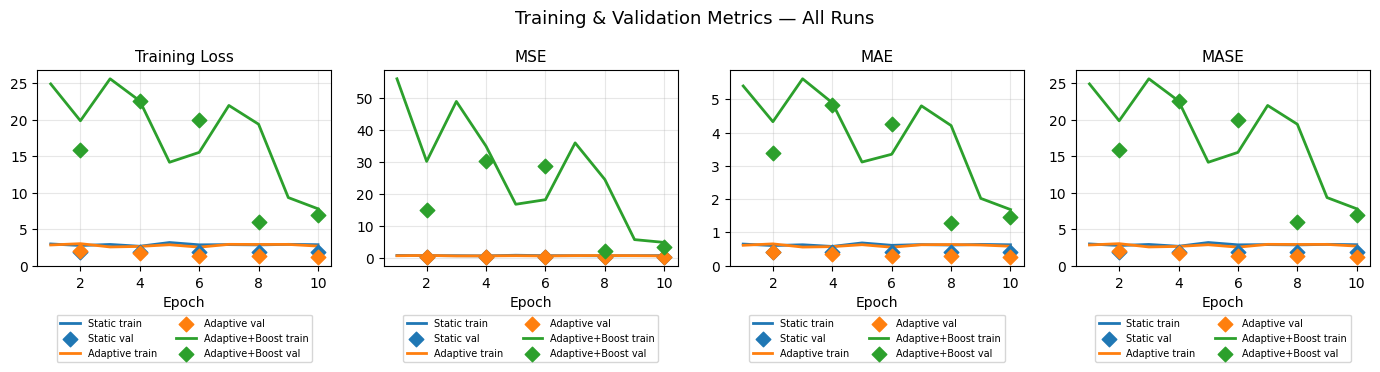

In [27]:
metrics_cfg = [
    ("loss",  "Training Loss"),
    ("mse",   "MSE"),
    ("mae",   "MAE"),
    ("mase",  "MASE"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_cfg):
    for run_key, run_dir in run_dirs.items():
        if run_dir is None:
            continue
        color = RUN_COLORS[run_key]
        label = RUN_LABELS[run_key]

        # Epoch-level train metric
        steps_tr, vals_tr = load_scalar(run_dir, f"train/{metric}_epoch")
        if steps_tr:
            ax.plot(steps_tr, vals_tr, color=color, lw=2, label=f"{label} train")

        # Validation metric (recorded every VAL_EVERY epochs)
        steps_val, vals_val = load_scalar(run_dir, f"val/{metric}")
        if steps_val:
            ax.scatter(
                steps_val, vals_val,
                color=color, marker="D", s=55, zorder=5,
                label=f"{label} val",
            )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.legend(
        fontsize=7,
        ncol=2,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
    )
    ax.grid(alpha=0.3)

plt.suptitle("Training & Validation Metrics — All Runs", fontsize=13)
plt.tight_layout()
plt.show()

---
## Part 5 — Learned Mixture Weights

At each training step the script logs the batch-averaged softmax weights via
`mixture/weight/<model_name>`. We plot these for `chronos2` and `moirai2`
side-by-side across all three runs, with exponential moving-average smoothing
(α = 0.15) to reduce step-level noise.

A weight close to 0.5 means the two models are treated equally; a weight above
0.5 means the mixture favours that model.

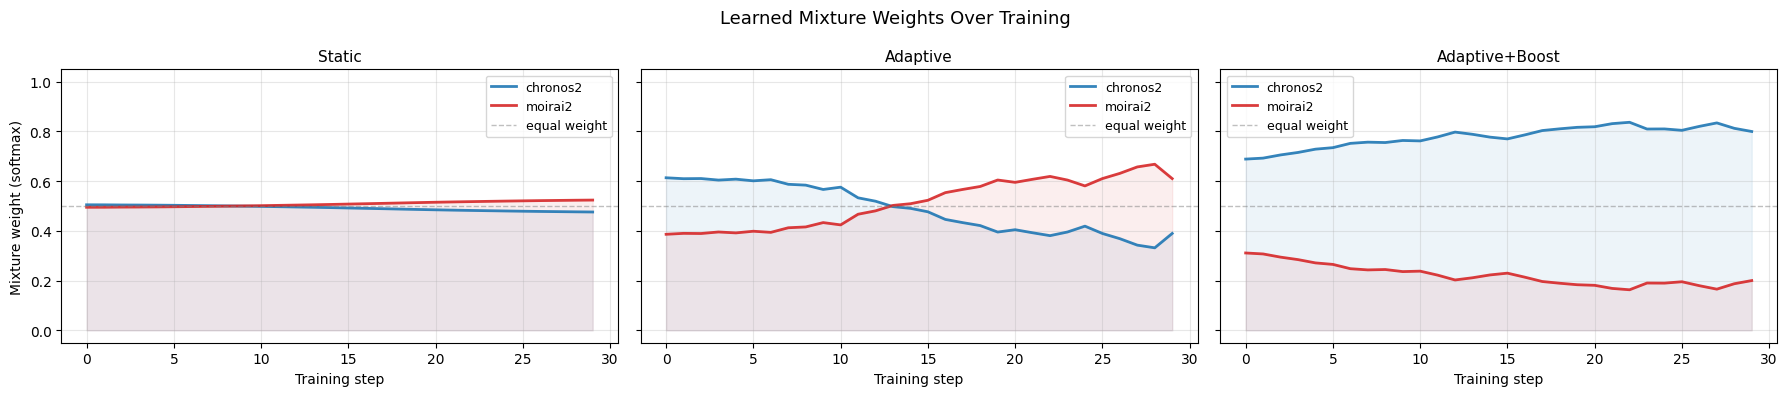

In [28]:
n_runs = sum(v is not None for v in run_dirs.values())
fig, axes = plt.subplots(1, n_runs, figsize=(6 * n_runs, 4), sharey=True)
if n_runs == 1:
    axes = [axes]

ax_iter = iter(axes)
for run_key, run_dir in run_dirs.items():
    ax = next(ax_iter)

    if run_dir is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(RUN_LABELS[run_key])
        continue

    has_data = False
    for model_name in MODEL_NAMES:
        steps, vals = load_scalar(run_dir, f"mixture/weight/{model_name}")
        if steps:
            smoothed = ema_smooth(vals, alpha=0.15)
            color = MODEL_COLORS[model_name]
            ax.plot(steps, smoothed, color=color, lw=2, label=model_name, alpha=0.9)
            ax.fill_between(steps, smoothed, alpha=0.08, color=color)
            has_data = True

    if not has_data:
        ax.text(
            0.5, 0.5, "No weight data",
            ha="center", va="center", transform=ax.transAxes, fontsize=9,
        )

    ax.axhline(0.5, color="gray", linestyle="--", lw=1, alpha=0.5, label="equal weight")
    ax.set_title(RUN_LABELS[run_key], fontsize=11)
    ax.set_xlabel("Training step")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Mixture weight (softmax)")
plt.suptitle("Learned Mixture Weights Over Training", fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

| Section | What we saw |
|---------|-------------|
| Data exploration | Series lengths, frequencies, and NaN rates for the `weather` subset |
| Training | Three variants trained end-to-end with frozen `chronos2` + `moirai2` backbones |
| Results | Test MASE / MSE / MAE across mixture variants and individual backbones |
| Training curves | Loss and metric convergence; validation at checkpoints |
| Weights | How the mixture distributes confidence between the two models over time |

To reproduce at larger scale, increase `EPOCHS`, `MAX_SERIES`, and switch `DEVICE` to `"cuda"`.

Launch TensorBoard to explore all scalars interactively:
```bash
tensorboard --logdir logs/
```